# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly import tenalg

---

## 1. Data import:

In [4]:
from pathlib import Path

data_dir = Path("../data/breast_cancer_zikry_wayne")
h5ad_files = sorted(data_dir.glob("*.h5ad"))
if not h5ad_files:
    raise FileNotFoundError(f"No .h5ad files found in {data_dir}")

adatas = [sc.read_h5ad(str(p)) for p in h5ad_files]

adata = sc.concat(
    adatas,
    join="inner",
    label="source_file",
    keys=[p.stem for p in h5ad_files],
    index_unique="-",
)

adata.obs["source_file"] = adata.obs["source_file"].str.removesuffix("_merged").values

In [5]:
# We subset to the intersection of the proteins selected in $\texttt{Selected features.ipynb}$:

# features_44PE = [
#     'nuclear_mean_pH2AX','nuclear_mean_53BP1', 'nuclear_mean_ECad', 
#     'nuclear_mean_HER2', 'nuclear_mean_cycD1', 'nuclear_mean_CDK4',
#     'nuclear_mean_cycE1', 'nuclear_mean_HES1', 'nuclear_mean_pRB',
#     'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 
#     'DNA_int', 'nuclear_mean_CycB1'
# ]

# features_134 = [
#     'nuclear_mean_CDK4', 'nuclear_mean_cycE1', 'nuclear_mean_pH2AX', 
#     'nuclear_mean_53BP1','nuclear_mean_p16', 'nuclear_mean_pRB',
#     'nuclear_mean_PH3','nuclear_mean_cycA2','nuclear_mean_Plk1',
#     'DNA_int'
# ]

# features_231 = [
#     'nuclear_mean_cycD1', 'nuclear_mean_CDK4', 'nuclear_mean_pH2AX', 
#     'nuclear_mean_ERa', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
#     'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
# ]

# features_453 = [
#     'nuclear_mean_pH2AX', 'nuclear_mean_pAKT', 'nuclear_mean_CDK4',
#     'nuclear_mean_RB', 'nuclear_mean_CDK2', 'nuclear_mean_CycB1',
#     'nuclear_mean_cycD1', 'nuclear_mean_cycE1', 'nuclear_mean_CDC25c', 
#     'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
#     'nuclear_mean_Plk1', 'DNA_int'
# ]

# features_BCK4 = [
#     'nuclear_mean_HES1', 'nuclear_mean_pH2AX', 'nuclear_mean_bCat',
#     'nuclear_mean_ERa', 'nuclear_mean_DAPI', 'nuclear_mean_CDK4',
#     'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
#     'nuclear_mean_Plk1', 'DNA_int'
# ]

# features_MCF7 = [
#     'nuclear_mean_HER2', 'nuclear_mean_cycE1', 'cyto_mean_CDC25c',
#     'cyto_mean_PR', 'cyto_mean_p21', 'nuclear_mean_CDC25c',
#     'nuclear_mean_cycA1', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
#     'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
# ]

# features_T47D = [
#     'nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX', 
#     'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
#     'nuclear_mean_CDK2', 'nuclear_mean_cycE1', 'nuclear_mean_pRB',
#     'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
#     'DNA_int'
# ]

# features_MCF10A = [
#     'nuclear_mean_ERa', 'nuclear_mean_pRB', 'pRB/RB', 
#     'nuclear_mean_HES1', 'nuclear_mean_Ki67', 'nuclear_mean_cycB2',
#     'nuclear_mean_cycD1', 'nuclear_mean_RB', 'nuclear_mean_pRB',
#     'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
#     'DNA_int'
# ]


In [30]:
# selected_features = list(
#     set(features_44PE) 
#     & set(features_134)
#     & set(features_231)
#     & set(features_453)
#     & set(features_BCK4)
#     & set(features_MCF7)
#     & set(features_T47D)
#     & set(features_MCF10A)
# )

# adata = adata[:, selected_features]

Removing any protein containing $``\texttt{pRB}''$:

In [32]:
not_prb = [f for f in adata.var_names if "pRB" not in f]
adata = adata[:, not_prb]

Understanding our data:

In [33]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (973416, 100)


In [34]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0-134_merged', '1-134_merged', '3-134_merged', '4-134_merged',
       '5-134_merged', '6-134_merged', '7-134_merged', '8-134_merged',
       '9-134_merged', '10-134_merged',
       ...
       '144074-T47D_merged', '144075-T47D_merged', '144076-T47D_merged',
       '144077-T47D_merged', '144084-T47D_merged', '144086-T47D_merged',
       '144088-T47D_merged', '144091-T47D_merged', '144093-T47D_merged',
       '144094-T47D_merged'],
      dtype='object', length=973416)

gene/feature names (column index): Index(['cyto_mean_ERa', 'cyto_mean_Ki67', 'cyto_mean_PR', 'cyto_mean_DAPI',
       'cyto_mean_HES1', 'cyto_mean_p38', 'cyto_mean_p16', 'cyto_mean_PH3',
       'cyto_mean_p65', 'cyto_mean_pAKT', 'cyto_mean_53BP1', 'cyto_mean_pS6',
       'cyto_mean_pERK', 'cyto_mean_pATR', 'cyto_mean_ECad', 'cyto_mean_AurB',
       'cyto_mean_pp130', 'cyto_mean_CDC25c', 'cyto_mean_p130',
       'cyto_mean_pcdc2', 'cyto_mean_CDH1', 'cyto_mean_NaKATPase',
       'cyto_mean_

In [35]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name,source_file
0-134_merged,1.0,0,0,G1,2.852778,174.067138,Diploid,Control,134
1-134_merged,1.0,0,1,G2,4.277782,7286.788861,Diploid,Control,134
3-134_merged,1.0,0,3,G1,2.058231,91.620798,Diploid,Control,134
4-134_merged,1.0,0,4,S,2.739487,2175.699147,Diploid,Control,134
5-134_merged,1.0,0,5,S,2.697213,3199.397408,Diploid,Control,134
...,...,...,...,...,...,...,...,...,...
144086-T47D_merged,8.0,0,144086,G1,1.975002,206.578002,Diploid,Dinaciclib,T47D
144088-T47D_merged,8.0,0,144088,G1,2.147560,188.380613,Diploid,Dinaciclib,T47D
144091-T47D_merged,8.0,0,144091,G1,2.080763,182.618456,Diploid,Dinaciclib,T47D
144093-T47D_merged,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib,T47D


In [36]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
RO-3306         0.293042
Palbociclib     0.141187
Control         0.120646
CVT-313         0.118843
Dinaciclib      0.105978
Talazoparib     0.095204
Samuraciclib    0.064504
PF-3600         0.060595
Name: count, dtype: float64

In [37]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,cyto_mean_ERa,cyto_mean_Ki67,cyto_mean_PR,cyto_mean_DAPI,cyto_mean_HES1,cyto_mean_p38,cyto_mean_p16,cyto_mean_PH3,cyto_mean_p65,cyto_mean_pAKT,...,nuclear_mean_cycB2,nuclear_mean_bCat,nuclear_mean_SKP2,nuclear_mean_E2F1,nuclear_mean_HER2,nuclear_mean_YAP1,nuclear_mean_CDT1,nuclear_mean_pCdc6,nuclear_mean_cycE2,DNA_int
0-134_merged,128.891473,682.753230,1219.166667,1517.728682,306.811370,1251.518088,662.940568,545.459948,185.443152,120.905685,...,421.897527,381.206125,226.175501,179.487633,116.204947,309.849234,660.297998,7134.395760,3554.537102,2.852778
1-134_merged,75.622660,9605.408867,1500.310345,1386.023645,169.667980,1011.889655,502.850246,978.914286,180.100493,117.350739,...,2273.139651,305.059850,847.447215,149.010806,103.637573,234.208645,168.842062,6078.343308,2158.676642,4.277782
3-134_merged,226.747604,423.990415,1475.236422,841.741214,212.792332,1390.230032,575.335463,559.412141,165.862620,131.389776,...,295.806723,441.515756,202.215336,143.250000,145.125000,268.738445,624.595588,5127.728992,2542.405462,2.058231
4-134_merged,122.927130,3195.395740,1468.034753,744.338565,241.318386,1017.356502,680.375561,686.201794,185.656951,136.104260,...,796.367844,357.511571,1002.887942,176.321559,102.467722,257.378806,261.270402,6593.686967,3281.298417,2.739487
5-134_merged,155.556344,5454.847382,1610.952972,961.984916,285.668146,1034.645075,652.214729,595.039929,180.217391,130.847382,...,673.765659,354.328294,1019.077754,188.511879,102.889849,255.292657,238.992441,7269.831533,3097.856371,2.697213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144086-T47D_merged,350.224665,1706.194073,6606.742830,1518.370937,1474.399618,3032.673996,1045.143403,535.826960,478.930210,194.162524,...,424.152637,5342.647587,265.560045,192.483726,118.208754,382.803591,498.648709,3086.870932,1658.060606,1.975002
144088-T47D_merged,275.733010,3745.796117,4022.415534,954.414563,1441.336893,2627.347573,651.882524,410.590291,280.242718,154.312621,...,397.565217,2868.506771,1946.116180,170.490378,111.822523,415.852459,807.243051,3154.683535,1389.324305,2.147560
144091-T47D_merged,246.028186,1267.385417,4550.008578,386.239583,1560.226716,2676.881740,647.207108,851.734069,299.743260,168.662990,...,379.368234,4208.327418,417.881100,177.077196,116.058563,362.409938,302.302573,3715.850044,1601.974268,2.080763
144093-T47D_merged,330.025751,2392.742489,7072.111588,1417.849785,1562.725322,3580.859800,1009.585122,607.746781,364.416309,210.494993,...,455.776796,3903.870718,271.385635,203.760221,115.297238,374.544751,414.617680,3537.779006,1664.910497,2.205912


(Optionally:) Exclude phases G0 and M from our data set:

In [38]:
condition_G0_M = (~adata.obs['GMM_phase_labels'].isin(['G0', 'M']))
adata = adata[condition_G0_M]

Calculating PHATE...
  Running PHATE on 10000 observations and 100 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.16 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.28 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.25 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.13 seconds.
  Calculated landmark operator in 1.38 seconds.
  Calculating optimal t...
    Automatically selected t = 26
  Calculated optimal t in 1.09 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.27 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.22 seconds.
Calculated PHATE in 4.50 seconds.


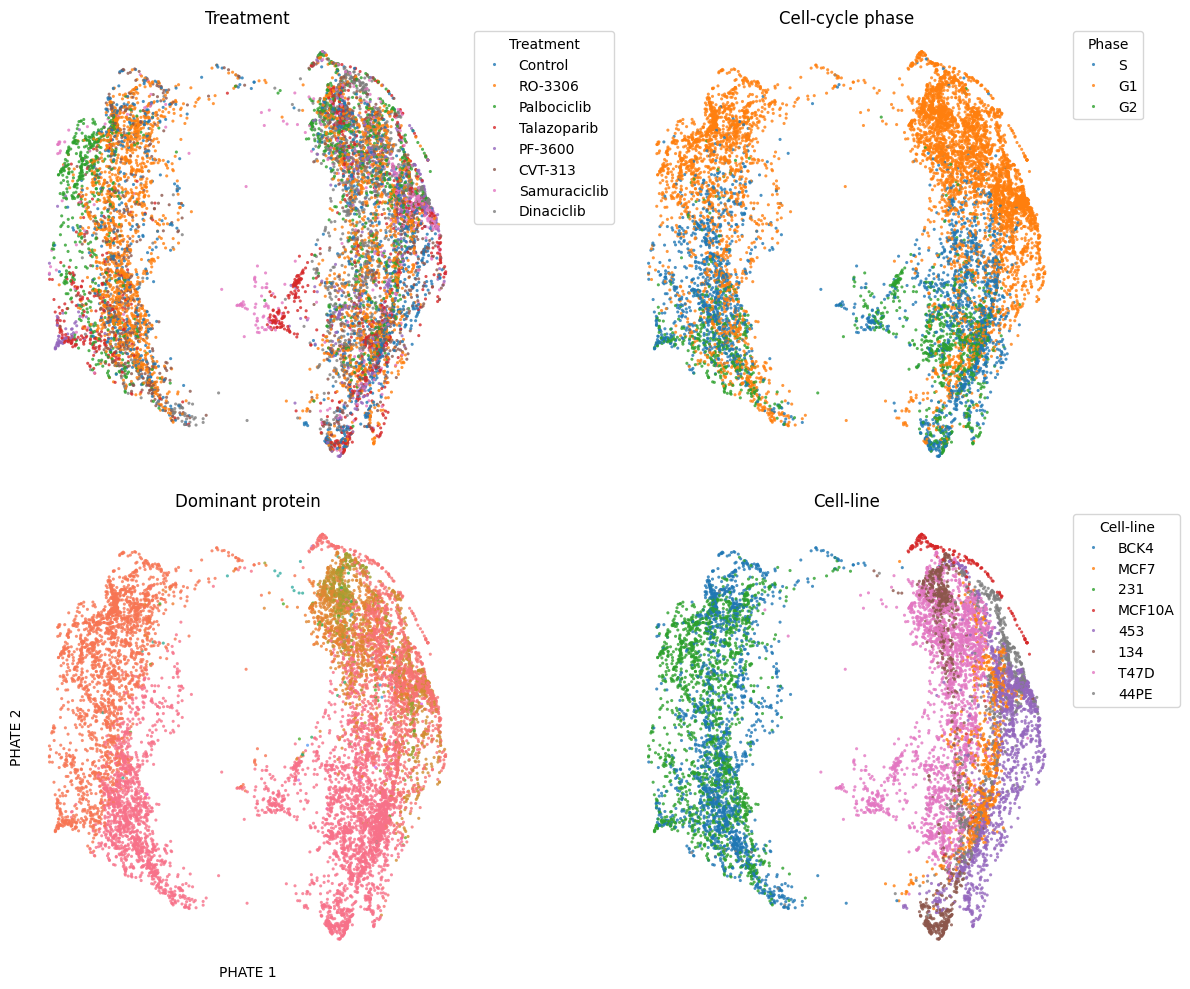

In [39]:
import phate

dot_size = 5

# PHATE on sampled data
adata_sub = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)
phate_op = phate.PHATE()
data_phate = phate_op.fit_transform(adata_sub.X)
dominant_protein = adata_sub.to_df().idxmax(axis=1)
cell_line = adata_sub.obs["source_file"].astype(str).values

phate = pd.DataFrame(
    data_phate, 
    columns=["PHATE 1", "PHATE 2"],
    index=adata_sub.obs_names,
)

phate["treatment"] = adata_sub.obs["drug_name"].astype(str).values
phate["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate["protein"] = np.asarray(adata_sub[:, "DNA_int"].X).ravel()
phate["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values
phate["cell_line"] = cell_line


# Set up visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
sns.despine(top=True, right=True, left=True, bottom=True)


# Treatment
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2]
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)

axes[2].get_legend().remove()  # Optionally remove dominant protein legend if too long


# Cell-line
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="cell_line",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[3]
)
axes[3].set_title("Cell-line")
axes[3].legend(
    title="Cell-line", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Final touches
for ax in axes:
    if ax == axes[2]: 
        ax.set_xlabel("PHATE 1")
        ax.set_ylabel("PHATE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

---

## 2. Data analysis:

We model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein} \times \textit{cell-line}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, let $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 5$, let $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 13$, and let $l \in \mathbb{N}$ be the number of cell-lines analyzed, here $l = 8$. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
\begin{split}
X & \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \times_4 L \\
        & = (\mathcal{G} \times_1 T \times_2 C \times_4 L) \times_3 P \\
        & = \mathcal{F}\times_3 P  
\end{split}
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, $L \in \mathbb{R}^{l_F \times l}$ are the cell-line loadings, and $\mathcal{F} \in \mathbb{R}^{t \times c \times p_F \times l}$ is a tensor encoding the effect of the protein-factors on the cell-cycle across treatments and cell-lines. (Note that $t_F$, $c_F$, $p_F$, and $l_F$ denote the treatment-facotrs, cell-cycle-phase-factors, protein-factors, and cell-line-factors respectively.)

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each $\texttt{(treatment, cell-cycle-phase, cell-line)}$ and obtaining our tensor by stacking across proteins and cell-lines.

In [40]:
def pseudobulk(adata):
    # Convert AnnData to DataFrame 
    adata_df = adata.to_df()
    
    # Group by drug_name and GMM_phase_labels, then get mean of each group
    pseudobulk_df = adata_df.groupby([adata.obs["drug_name"], adata.obs["GMM_phase_labels"], adata.obs["source_file"]], observed=True).mean()
    
    # z-scale across each protein 
    pseudobulk_df_scales = (pseudobulk_df - pseudobulk_df.mean()) / pseudobulk_df.std()
    
    # Reshape to (n_treatments, n_phases, n_proteins, n_cell_lines)
    return_tensor = pseudobulk_df_scales.values.reshape(len(adata.obs["drug_name"].cat.categories), len(adata.obs["GMM_phase_labels"].cat.categories), -1, len(np.unique(adata.obs["source_file"])))
    return return_tensor

In [41]:
pseudobulk_tensor = pseudobulk(adata)
print(f'Pseudobulk tensor shape: {pseudobulk_tensor.shape}')

print("Example pseudobulk values for the first protein (HES1), in fist cell-line:")
pd.DataFrame(pseudobulk_tensor[:, :, 0, 0], index=adata.obs["drug_name"].cat.categories, columns=adata.obs["GMM_phase_labels"].cat.categories)

Pseudobulk tensor shape: (8, 3, 100, 8)
Example pseudobulk values for the first protein (HES1), in fist cell-line:


,G1,G2,S
CVT-313,-0.188237,0.022011,-0.280084
Control,0.265185,0.720106,0.362860
Dinaciclib,-0.314948,-0.140400,-0.290194
PF-3600,2.270879,1.562931,1.287555
Palbociclib,2.409974,1.494779,1.153786
RO-3306,0.781221,0.529861,0.351321
Samuraciclib,0.010895,-0.490956,-0.302351
Talazoparib,1.079748,0.924311,0.680677


In [42]:
treatments = list(adata.obs["drug_name"].cat.categories)
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in adata.var_names]
cell_lines = list(np.unique(adata.obs["source_file"]))

In [43]:
def HOSVD(tensor, truncation_rank=None):
    dims = tensor.shape
    
    if truncation_rank is None:
        truncation_rank = dims
    
    factors = []
    for i, _ in enumerate(dims): 
        matrix = tl.unfold(tensor, mode=i)
        
        rank = np.linalg.matrix_rank(matrix)
        factor = np.linalg.svd(matrix, full_matrices=False)[0][:, :rank]
        
        factors.append(factor[:, :truncation_rank[i]])
    
    factors_transposed = [f.T for f in factors]
    
    core = tenalg.multi_mode_dot(tensor, factors_transposed)
        
    return core, factors

### 2.2 Protein Rank-Selection:

We consider first the protein rank. To do so, we compute Tucker decompositions of our tensor, keeping the ranks of the other axes fixed at the maximum. 

In [84]:
err_dict = {}

for i in range(len(proteins)):
    truncation_rank = [pseudobulk_tensor.shape[0], pseudobulk_tensor.shape[1], i+1, pseudobulk_tensor.shape[3]]
    core, factors = HOSVD(pseudobulk_tensor, truncation_rank=truncation_rank)
    
    recon = tenalg.multi_mode_dot(core, factors)
    err = np.linalg.norm(recon - pseudobulk_tensor) / np.linalg.norm(pseudobulk_tensor)
    
    err_dict[i+1] = err

We interpolate the first an the last value and compute the difference between the reconstruction loss and the interpolation line. The value to be chosen is that which maximizes the difference. 

In [ ]:
start_err = err_dict[1]
end_err = err_dict[len(err_dict)]
steps = len(err_dict)

interpol_line = {i: (start_err * (((steps-1) - (i-1))/(steps-1)) + end_err * ((i-1)/(steps-1))) for i in range(1, steps+1)}
diff = {i: interpol_line[i] - err_dict[i] for i in range(1, steps+1)}

n_protein_factors = max(diff, key=diff.get)
print(f"Maximum difference at step {n_protein_factors}: {diff[n_protein_factors]}")

Maximum difference at step 28: 0.3654681945402755


After inspecting the heatmaps that follow, we may also choose 10 protein factors:

In [126]:
n_protein_factors = 10

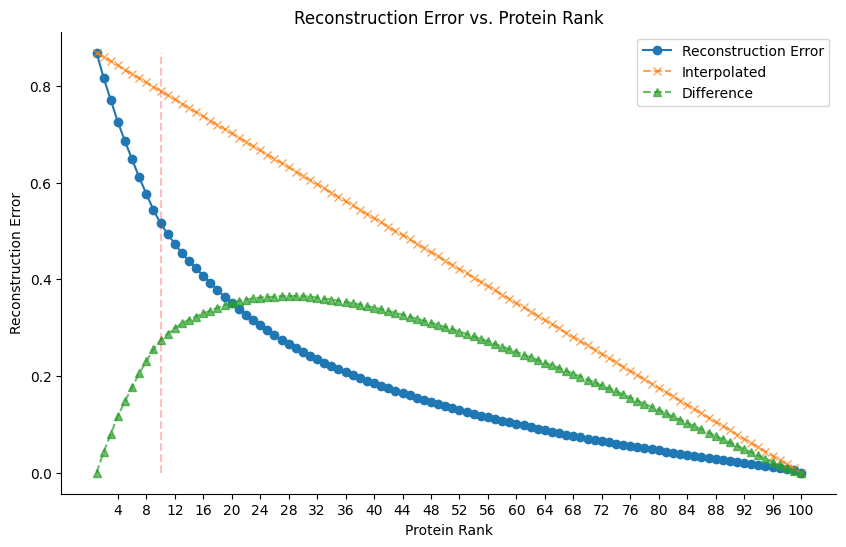

In [127]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

ax.set_ylabel("Reconstruction Error")
ax.set_xlabel("Protein Rank")
ax.set_xticks([k for k in err_dict if k % 4 == 0])

ax.spines[["top", "right"]].set_visible(False)

ax.plot(list(err_dict.keys()), list(err_dict.values()), marker='o')
ax.plot(list(interpol_line.keys()), list(interpol_line.values()), alpha=0.7, marker='x', linestyle='--')
ax.plot(list(diff.keys()), list(diff.values()), alpha=0.7, marker='^', linestyle='--')
ax.vlines(n_protein_factors, 0, err_dict[1], colors='red', alpha=0.25, linestyle='--')

plt.legend(["Reconstruction Error", "Interpolated", "Difference"])
plt.title("Reconstruction Error vs. Protein Rank")
plt.show()

In [128]:
truncation_rank = [pseudobulk_tensor.shape[0], pseudobulk_tensor.shape[1], n_protein_factors, pseudobulk_tensor.shape[3]]
core, factors = HOSVD(pseudobulk_tensor, truncation_rank=truncation_rank)

treatment_loadings = factors[0]
cell_phase_loadings = factors[1]
protein_loadings = factors[2]
cell_line_loadings = factors[3]

### 2.3 Protein loadings on Tensor Components:

In [129]:
def matrix_heatmap(matrix, xticks=None, yticks=None, xlabel=None, ylabel=None, title=None, x_tick_size=8, y_tick_size=8, text_size=8):
    fig = plt.figure(figsize=(16, 14))
    ax = fig.add_subplot(1, 1, 1)

    vmax = np.abs(matrix).max() or 1.0

    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

    if xticks is not None:
        ax.set_xticks(np.arange(len(xticks)))
        ax.set_xticklabels(xticks, fontsize=x_tick_size)
    else:
        ax.set_xticks(np.arange(matrix.shape[1]))

    if yticks is not None:
        ax.set_yticks(np.arange(len(yticks)))
        ax.set_yticklabels(yticks, fontsize=y_tick_size)
    else: 
        ax.set_yticks(np.arange(matrix.shape[0]))
    
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=text_size,
                color="white" if abs(matrix[i, j]) > 0.6 * vmax else "black"
            )
                
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, pad=0.06)

    if title:
        plt.title(title, fontsize=13)
        
    plt.show()

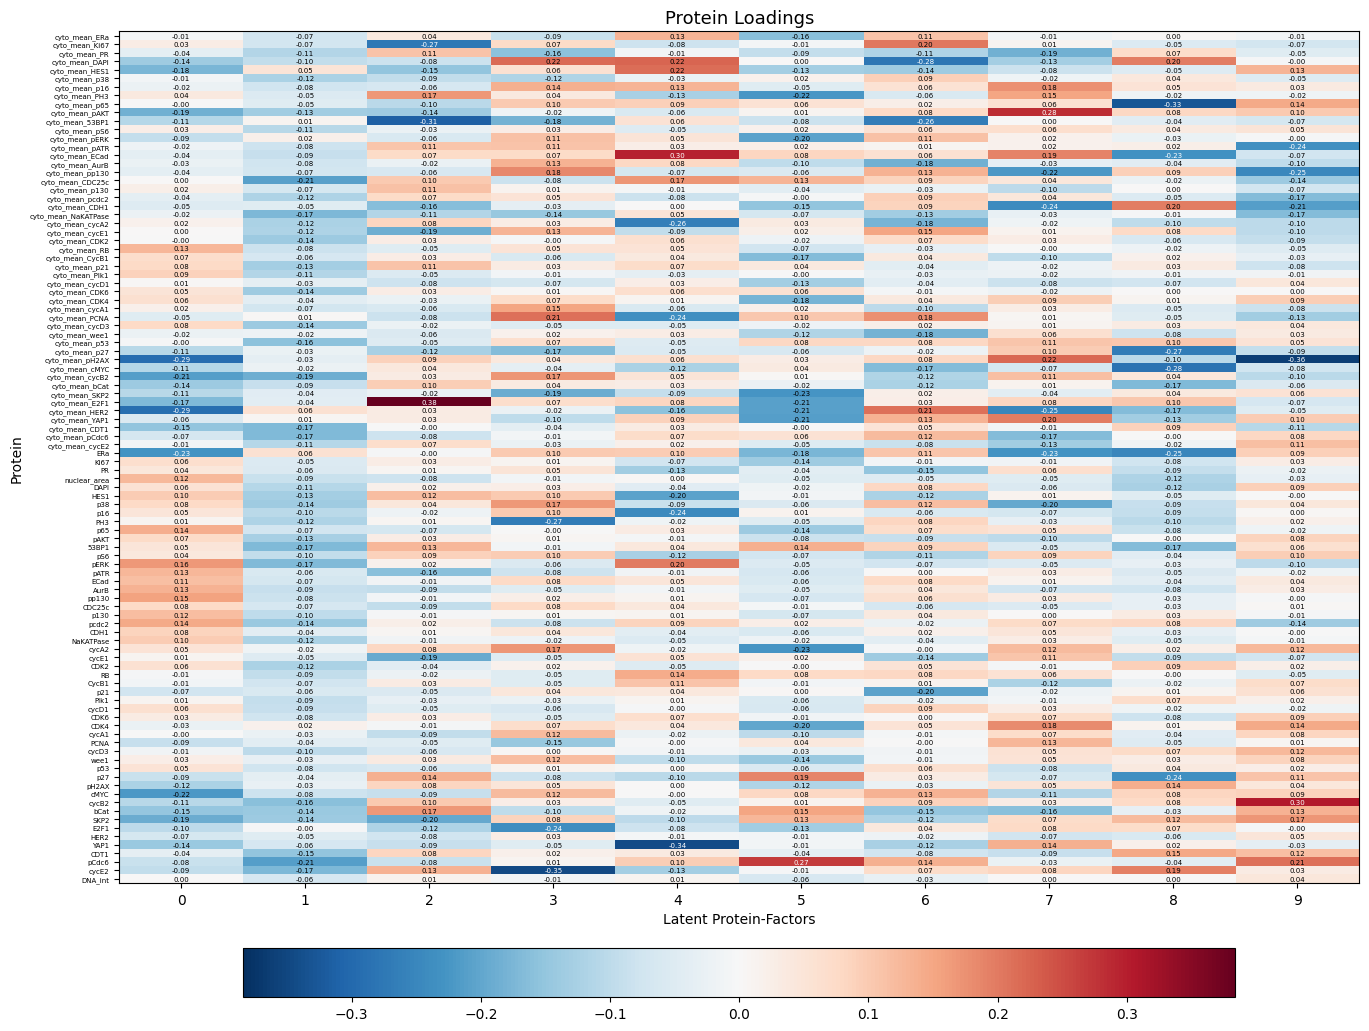

In [135]:
matrix_heatmap(
    protein_loadings, 
    yticks=proteins,
    xlabel="Latent Protein-Factors", ylabel="Protein", 
    title="Protein Loadings", 
    y_tick_size=5, text_size=5
)

We now also consider the tensor $\mathcal{F} = \mathcal{G} \times_1 T \times_2 C \times_4 L \in \mathbb{R}^{t \times c \times p_F \times l}$. We may obtain matrices $\mathbf{F}^{(T)} \in \mathbb{R}^{p_F \times t}$, $\mathbf{F}^{(C)} \in \mathbb{R}^{p_F \times c}$, and $\mathbf{F}^{(C)} \in \mathbb{R}^{p_F \times l}$, by averaging over the remaining two dimensions. 

<!-- Considering the mode-$3$ matricization of $\mathcal{F}$, namely $\mathbf{F}_{(3)} \in \mathbb{R}^{p \times (t_F \cdot c_F \cdot l_F)}$. We obtain three matrices $\mathbf{F}^{(T)} \in \mathbb{R}^{p \times t_F}$, $\mathbf{F}^{(C)} \in \mathbb{R}^{p \times c_F}$, and $\mathbf{F}^{(C)} \in \mathbb{R}^{p \times l_F}$, informing us how the individual proteins effect the respective latent factors. -->

In [131]:
F = tenalg.multi_mode_dot(
    core,
    [treatment_loadings, cell_phase_loadings, cell_line_loadings],
    modes=[0, 1, 3],
)

Proteins by treatment:

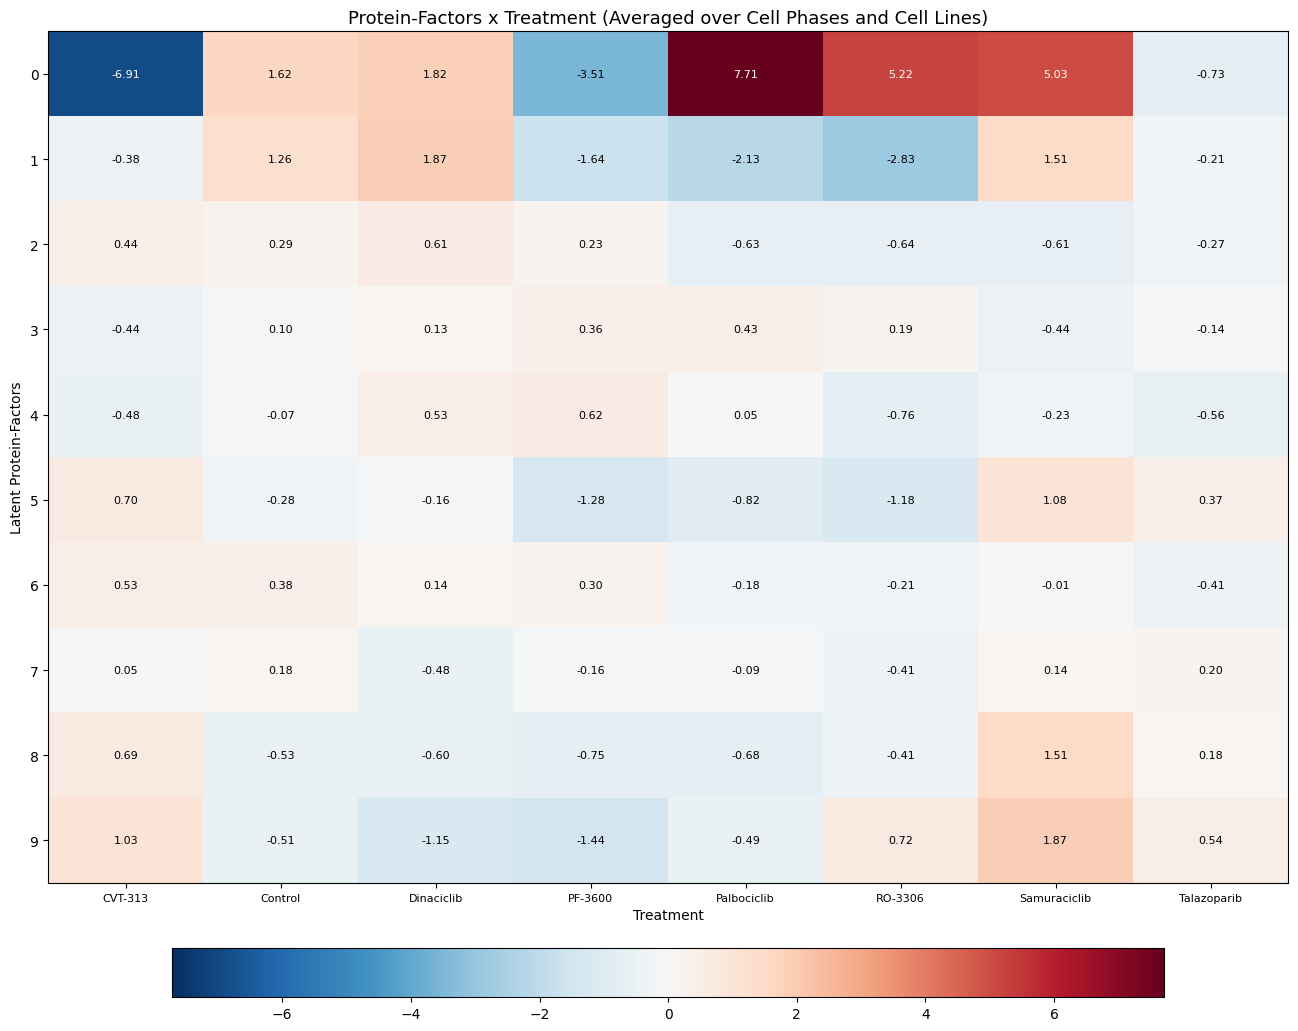

In [132]:
proteins_treatment_loadings = F.mean(axis=(1, 3)).T  # average over: (1) cell-cycle phases, (3) cell-lines
proteins_treatment = proteins_treatment_loadings @ treatment_loadings.T

matrix_heatmap(
    proteins_treatment, 
    xticks=treatments,
    xlabel="Treatment", ylabel="Latent Protein-Factors", 
    title="Protein-Factors x Treatment (Averaged over Cell Phases and Cell Lines)"
)

Proteins by cell-cycle phase:

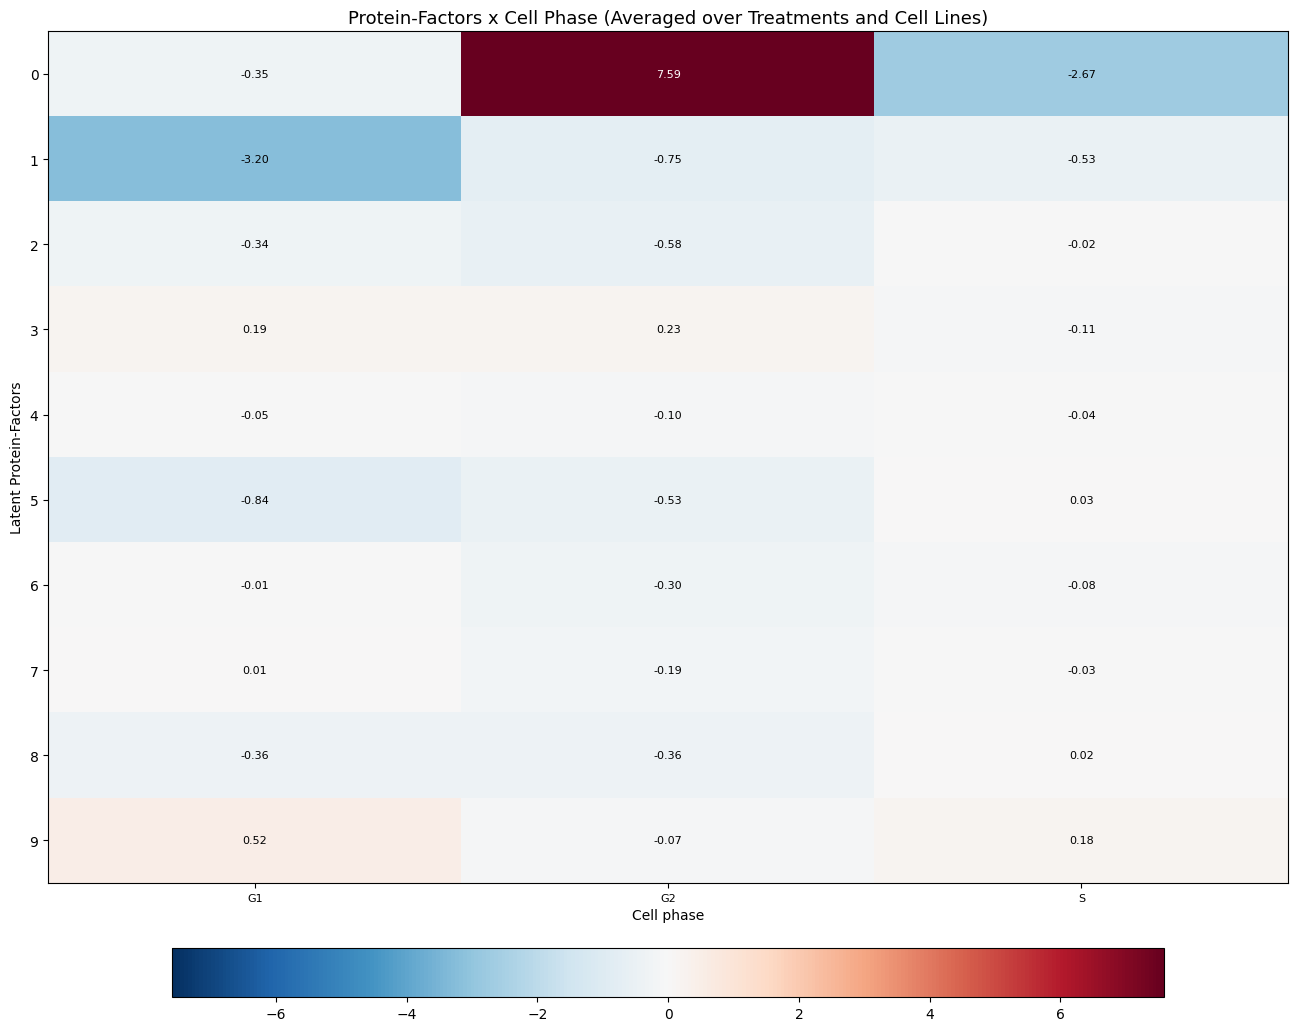

In [133]:
proteins_phase_loadings = F.mean(axis=(0, 3)).T  # average over: (0) treatments, (3) cell-lines
proteins_phase = proteins_phase_loadings @ cell_phase_loadings.T

matrix_heatmap(
    proteins_phase, 
    xticks=phases, 
    xlabel="Cell phase", ylabel="Latent Protein-Factors", 
    title="Protein-Factors x Cell Phase (Averaged over Treatments and Cell Lines)"
)

Proteins by cell lines:

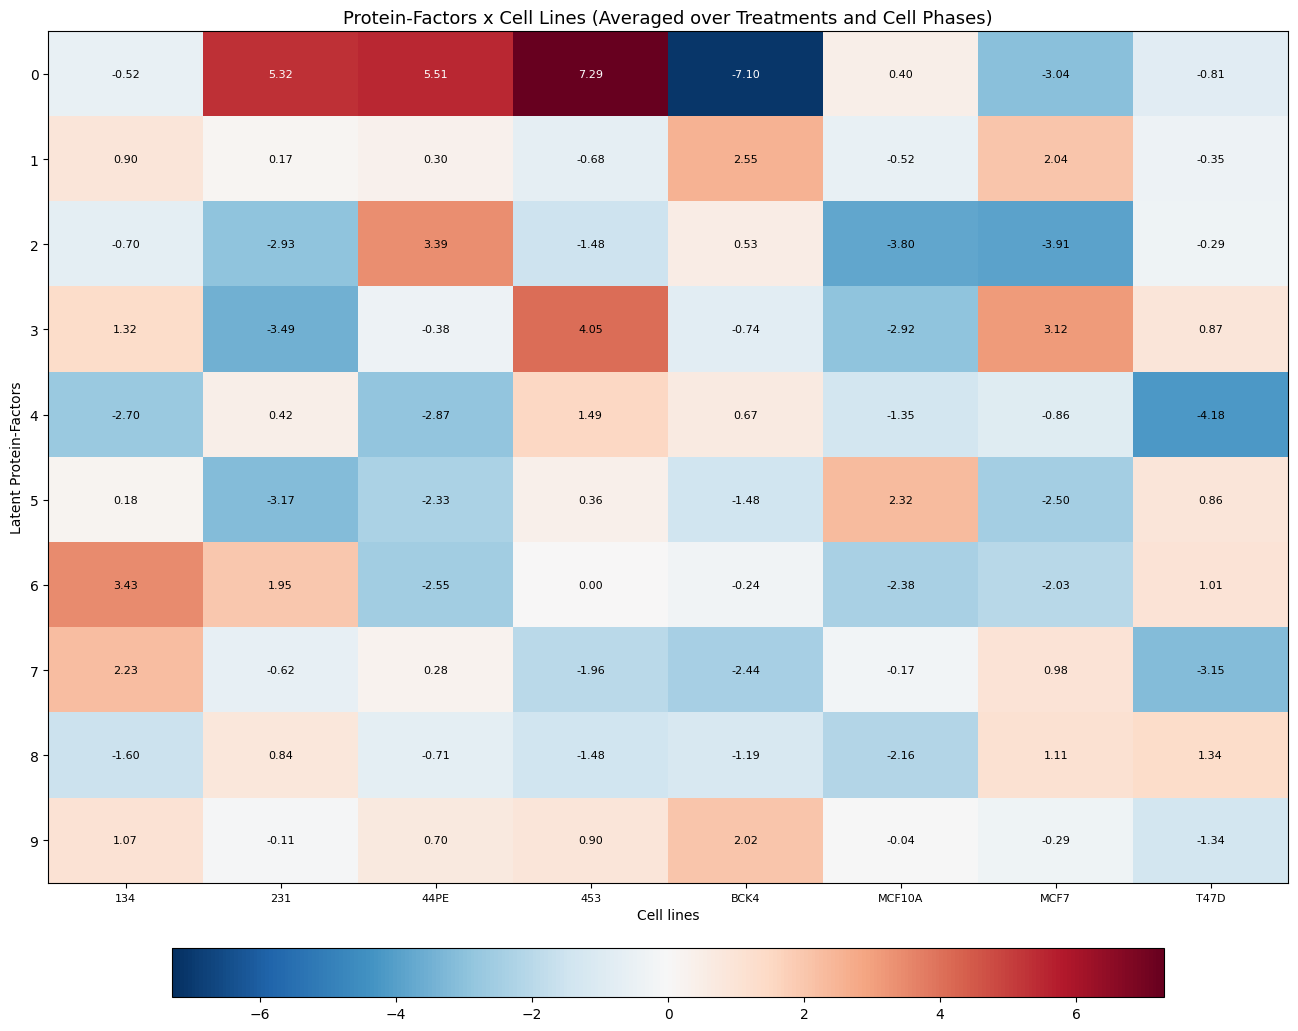

In [134]:
proteins_lines_loadings = F.mean(axis=(0, 1))  # average over: (0) treatments, (1) cell-cycle phases
proteins_lines = proteins_lines_loadings @ cell_line_loadings.T

matrix_heatmap(
    proteins_lines, 
    xticks=cell_lines,
    xlabel="Cell lines", ylabel="Latent Protein-Factors", 
    title="Protein-Factors x Cell Lines (Averaged over Treatments and Cell Phases)"
)

---